# Naive Bayes Classifier for Bank Fraud Detection
This notebook trains a Naive Bayes model on cleaned fraud data and evaluates it using standardized metrics.

## 1. Imports and Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, average_precision_score, 
                             roc_auc_score, precision_recall_curve, f1_score, make_scorer)
from sklearn.feature_selection import SelectFromModel, mutual_info_classif
from scipy.stats import uniform, randint
from xgboost.callback import EarlyStopping


## 2. Evaluation Function

In [5]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC:                   {roc_auc:.4f}")

        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

## 3. Load and Prepare Data

In [6]:
# Concatenate SMOTEd folds 1-4 for training
train_folds = [pd.read_csv(f"../../data/preprocessed/fold_{i}_train.csv") for i in range(1, 5)]
val_fold = pd.read_csv("../../data/preprocessed/fold_5_val.csv")

train_df = pd.concat(train_folds, ignore_index=True)
val_df = val_fold

X_train = train_df.drop(columns=['fraud_bool'])
y_train = train_df['fraud_bool']
X_val = val_df.drop(columns=['fraud_bool'])
y_val = val_df['fraud_bool']

## 4. Train Naive Bayes Model with Hyperparameter Tuning & 5. Evaluate Model

Best Threshold: 0.997
Best F1 Score: 0.1669
Classification Report:
              precision    recall  f1-score   support

           0     0.9916    0.9846    0.9881    178711
           1     0.1337    0.2208    0.1665      1920

    accuracy                         0.9765    180631
   macro avg     0.5626    0.6027    0.5773    180631
weighted avg     0.9825    0.9765    0.9794    180631


Confusion Matrix:
[[175963   2748]
 [  1496    424]]

Precision: 0.1337
Recall:    0.2208
F1 Score:  0.1665
AUC-PR (Average Precision): 0.0909
ROC AUC:                   0.7913


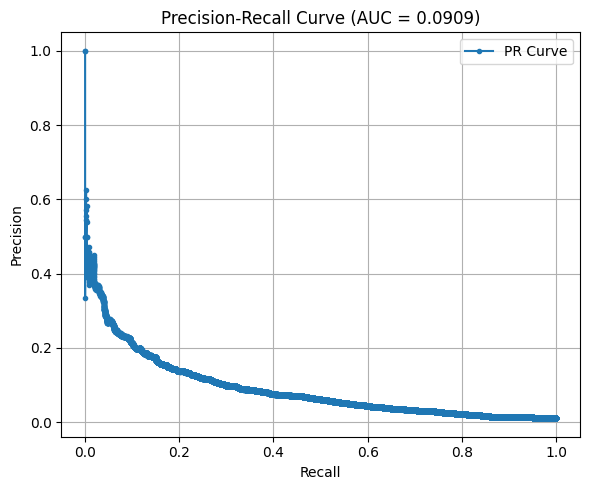

{'precision': 0.13366960907944514,
 'recall': 0.22083333333333333,
 'f1_score': 0.16653574234092694,
 'confusion_matrix': [[175963, 2748], [1496, 424]],
 'auc_pr': 0.09086021807741157,
 'roc_auc': 0.7912520394892687}

In [13]:
# 1. Feature Importance Selection using Mutual Information
importances = mutual_info_classif(X_train, y_train, discrete_features='auto', random_state=42)
importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
top_features = importance_df.sort_values(by='importance', ascending=False)['feature'][:30]

X_train_top = X_train[top_features]
X_val_top = X_val[top_features]

# 2. Skip class weights — GaussianNB doesn’t support scale_pos_weight
# (But we can still manually tune if you'd like)

# 3. No hyperparameters to tune really, but to follow structure:
model = GaussianNB()

# Fit the model
model.fit(X_train_top, y_train)

# 4. Predict probabilities
y_proba = model.predict_proba(X_val_top)[:, 1]

# 5. Threshold tuning
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold:.3f}")
print(f"Best F1 Score: {best_f1:.4f}")

# 6. Final prediction and evaluation
y_pred_final = (y_proba > best_threshold).astype(int)
evaluate_model(y_val, y_pred_final, y_proba)